# Session 03 — Training a tiny Transformer

In Session 02, we built attention and a decoder-only Transformer. Here the architecture is supplied so that we can focus on **training**.

Everything runs on CPU. The goal is not to obtain a good French language model; it is to understand, measure, and diagnose learning.

## Learning objectives

By the end of the practical, you should be able to:

- understand training loop
- its difference from evaluation / val loss
- overfit and underfit a model and understand the difference between the two
- (optinal) know how to tune hyperparameters and the effect of learning rate and batch size on training and validation loss

Approximate core runtime on a laptop CPU: a few minutes. Exact speed depends on the machine.

## 0. The training paradigm

Training repeatedly applies this loop:

    sample a batch
          ↓
    model(x) → logits
          ↓
    loss(logits, targets)
          ↓
    loss.backward() → gradients
          ↓
    optimizer.step() → updated parameters
          ↺

The **model** maps inputs to predictions. The **loss** gives one scalar measuring their error. Backpropagation computes how each parameter contributed to that error. The **optimizer** uses those gradients to update the parameters.

For plain SGD, one parameter is updated approximately as:

$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

where $\eta$ is the learning rate. The optimizer does not compute the gradients: <code>loss.backward()</code> does.

### Mini-vocabulary

- An **example** is one input–target sequence pair.
- A **batch** is a group of examples processed together. Batch size controls how many.
- A **step** (or iteration) is one optimizer update.
- An **epoch** is one pass through a finite dataset. Because we randomly sample overlapping text windows here, steps are a clearer compute budget than exact epochs.

## 1. Setup and data

We use character-level next-token prediction. For the text “chat” and a context of length 3:

- input: <code>c h a</code>
- targets: <code>h a t</code>

Every position is therefore a supervised prediction. We retain only part of the news corpus to keep the practical fast.

In [1]:
from pathlib import Path
import math
import time

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

SEED = 39
torch.manual_seed(SEED)
device = torch.device("cpu")

print("device:", device)

device: cpu


In [2]:
data_path = Path("frnews.txt")

# TODO: open file and read text
with open(data_path, 'r', encoding="utf-8") as f:
    text = f.read()

# TODO: remove date, extract text then join into a single string (only take the first 120k characters for speed)
lines = []
for line in text.splitlines():
    lines.append(line.split(':', 1)[1].strip())

text = '\n'.join(lines)[:120_000]

# TODO: map characters to integers and vice versa
chars = sorted(set(text))
stoi = {character: index for index, character in enumerate(chars)}
itos = {index: character for character, index in stoi.items()}

def encode(string):
    """Transform a string into a list of integers."""
    return [stoi[character] for character in string]

def decode(indices):
    """Transform a list of integers into a string."""
    return "".join(itos[int(index)] for index in indices)

# Encode the text into a tensor 
data = torch.tensor(encode(text), dtype=torch.long)
split_index = int(0.9 * len(data))  ## What is this?
train_data = data[:split_index]
val_data = data[split_index:]

vocab_size = len(chars) # TODO
BLOCK_SIZE = 32

print(f"characters used: {len(data):,}")
print(f"vocabulary size: {vocab_size}")
print(f"train/validation: {len(train_data):,} / {len(val_data):,}")

characters used: 120,000
vocabulary size: 101
train/validation: 108,000 / 12,000


### Why split the data?

- **Training set:** batches used to compute gradients and update parameters.
- **Validation set:** unseen batches used only to estimate generalization and choose hyperparameters.
- **Test set:** a final untouched set used after choices are finished. We omit it here to keep the lab compact.

The split happens before sampling windows, so no validation target is used in a training update.

🟧 Questions:

1. What would be wrong with selecting the best learning rate using training loss only?
2. Why must we not call <code>backward()</code> on validation loss?

In [3]:
def sample_batch(source, batch_size, block_size=BLOCK_SIZE, generator=None):
    """Sample random next-character examples from one 1-D token tensor."""
    starts = torch.randint(
        low=0,
        high=len(source) - block_size,
        size=(batch_size,),
        generator=generator,  # this is equivalent to a random seed, for reproducibility
    )
    x = torch.stack([source[i:i + block_size] for i in starts])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in starts])
    return x.to(device), y.to(device)

xb, yb = sample_batch(train_data, batch_size=4)
print("x shape:", tuple(xb.shape))
print("y shape:", tuple(yb.shape))
print("input example: ", repr(decode(xb[0])))
print("target example:", repr(decode(yb[0])))

x shape: (4, 32)
y shape: (4, 32)
input example:  'rts, sécurité... On a dressé le '
target example: 'ts, sécurité... On a dressé le b'


## 2. Tiny causal Transformer recap

The architecture from Session 02 now lives in [tiny_transformer.py](tiny_transformer.py). Importing it as a normal Python module keeps this notebook focused on training.

Two details in that module are essential for language modelling:

1. A **causal mask** prevents a position from seeing future target characters.
2. Every block receives the output of the preceding block.

The model is intentionally tiny.

In [4]:
from tiny_transformer import CausalSelfAttention, TinyTransformer

# CausalSelfAttention is available for inspection, while TinyTransformer is
# the complete model used by all training experiments below.
def make_model(d_model=32, num_heads=4, d_ff=64, num_layers=1):
    return TinyTransformer(
        vocab_size,
        d_model=d_model,
        num_heads=num_heads,
        d_ff=d_ff,
        num_layers=num_layers,
        max_len=BLOCK_SIZE,
    ).to(device)


model = make_model()
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"parameters: {parameter_count:,}")

with torch.no_grad():
    initial_logits = model(xb)
    initial_loss = F.cross_entropy(
        initial_logits.reshape(-1, vocab_size),
        yb.reshape(-1),
    )
print("logits shape:", tuple(initial_logits.shape))
print(f"initial loss: {initial_loss.item():.3f}")
print(f"uniform-guess reference log(V): {math.log(vocab_size):.3f}")

parameters: 15,968
logits shape: (4, 32, 101)
initial loss: 4.802
uniform-guess reference log(V): 4.615


🟧 Concept check:

- Why do the logits have shape <code>(batch, context, vocabulary)</code>?
- Why are both logits and targets flattened for cross-entropy?
- A random model is not perfectly uniform, but why should its loss be near $\log(V)$?
- What failure would you expect if the causal mask were removed during training?

## 3. Exercise 1 — One update by hand

Complete the five core operations. Their order matters.

Useful shapes:

- logits: <code>(B, T, V)</code>
- targets: <code>(B, T)</code>
- cross-entropy expects <code>(N, C)</code> and <code>(N)</code>, so use <code>reshape</code>.

In [5]:
torch.manual_seed(7)
demo_model = make_model()
optimizer = torch.optim.SGD(demo_model.parameters(), lr=0.1)

xb, yb = sample_batch(train_data, batch_size=16)
before = demo_model.head.weight.detach().clone()

# TODO 1: clear old gradients
optimizer.zero_grad()
# TODO 2: compute logits
logits = demo_model(xb)
# TODO 3: compute cross-entropy loss (flatten logits and targets)
loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
# TODO 4: backpropagate
loss.backward()
# TODO 5: update the parameters
optimizer.step()

print(f"loss before update: {loss.item():.3f}")

after = demo_model.head.weight.detach()
print(f"maximum head-weight change: {(after - before).abs().max().item():.6f}")

total_grad_norm = torch.sqrt(sum(
    parameter.grad.square().sum()
    for parameter in demo_model.parameters()
    if parameter.grad is not None
))
print(f"gradient norm: {total_grad_norm.item():.3f}")

with torch.no_grad():
    new_logits = demo_model(xb)
    new_loss = F.cross_entropy(
        new_logits.reshape(-1, vocab_size),
        yb.reshape(-1),
    )

print(f"loss on same batch after update: {new_loss.item():.3f}")


loss before update: 4.766
maximum head-weight change: 0.009260
gradient norm: 0.497
loss on same batch after update: 4.742


The loss after one step is measured on the **same batch**, so a small decrease only proves that the update fitted that batch slightly better. It does not prove generalization.

🟧 Questions:

1. What happens if <code>optimizer.zero_grad()</code> is removed?
2. What happens if <code>loss.backward()</code> is removed?
3. Why are parameters inspected with <code>detach()</code>?
4. Why might an excessively large learning rate increase the loss?

## 4. Exercise 2 — A complete training loop

A useful loop does more than update weights. It periodically:

- switches to evaluation mode;
- measures several **fixed** training and validation batches;
- records both losses;
- switches back to training mode.

Using fixed evaluation batches reduces noise and makes experiment comparisons fair.

We will distinguish **three losses**:

1. **SGD minibatch loss:** computed on the current random training batch and used by `backward()`. It is recorded every update and is noisy.
2. **Training-split evaluation loss:** averaged over fixed batches from the training split under `model.eval()` and `no_grad()`. It measures how well the model fits the training distribution.
3. **Validation-split evaluation loss:** computed in exactly the same evaluation procedure, but on text never used for parameter updates. It estimates generalization.

This model has no dropout, so `train()` and `eval()` currently produce the same operations. The data source, fixed sampling, averaging, and absence of gradient updates still make the three measurements different.

In [6]:
@torch.no_grad()
def estimate_losses(
    model,
    train_source,
    val_source,
    *,
    batch_size=32,
    eval_batches=5,
):
    was_training = model.training
    model.eval()
    result = {}

    # Recreate the same batches on every call and for every experiment.
    for split_name, source in [("train", train_source), ("val", val_source)]:
        
        # Random-seed like for reproducibility
        generator = torch.Generator().manual_seed(
            2026 if split_name == "train" else 2027
        )
        
        # Loss is estimated over a few batches instead of one unique batch
        losses = []
        for _ in range(eval_batches):
            xb_eval, yb_eval = sample_batch(
                source,
                batch_size=batch_size,
                generator=generator,
            )
            logits = model(xb_eval)
            loss = F.cross_entropy(
                logits.reshape(-1, model.vocab_size),
                yb_eval.reshape(-1),
            )
            losses.append(loss.item())
        result[split_name] = sum(losses) / len(losses)

    model.train(was_training)
    return result

In [14]:
def train_model(
    model,
    train_source,
    val_source,
    *,
    lr=0.1,
    batch_size=32,
    eval_batch_size=64,
    steps=200,
    eval_interval=20,
    eval_batches=5,
    seed=123,
):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    history = {
        "step": [],
        "train_loss": [],
        "val_loss": [],
        "batch_step": [],
        "batch_loss": [],
    }
    train_generator = torch.Generator().manual_seed(seed)
    started = time.perf_counter()
    
    for step in range(steps + 1):
        # TODO 3: At eval_interval, call estimate_losses and log it.
        if step % eval_interval == 0 or step == steps:
            losses = estimate_losses(
                model,
                train_source,
                val_source,
                batch_size=eval_batch_size,
                eval_batches=eval_batches,
            )
            history["step"].append(step)
            history["train_loss"].append(losses["train"])
            history["val_loss"].append(losses["val"])

        if step == steps:
            break
        
        model.train()
        # TODO 2: sample a training batch.
        xb, yb = sample_batch(train_source, batch_size=batch_size, generator=train_generator)
        
        # TODO 1: loop over steps. clear gradients, forward, compute loss, record batch loss, backward, update.
        # training loop
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        history["batch_step"].append(step + 1)     # only for stroring
        history["batch_loss"].append(loss.item())  # only for storing
        optimizer.step()
        
    
    # Important: validation data must only appear in estimate_losses.

    history["elapsed_seconds"] = time.perf_counter() - started
    return history

### First complete run: SGD

We start with SGD because its update rule is easy to interpret. The run is short; do not expect fluent generated text.

Before running, predict the plot:

- Should training loss decrease?
- Should validation loss decrease?
- Must either curve decrease at every checkpoint?

In [15]:
torch.manual_seed(10)
sgd_model = make_model()
sgd_history = train_model(
    sgd_model,
    train_data,
    val_data,
    lr=0.2,
    batch_size=32,
    steps=240,
    eval_interval=20,
)

print(f"runtime: {sgd_history['elapsed_seconds']:.1f} s")
print(f"train loss: {sgd_history['train_loss'][0]:.3f} → {sgd_history['train_loss'][-1]:.3f}")
print(f"val loss:   {sgd_history['val_loss'][0]:.3f} → {sgd_history['val_loss'][-1]:.3f}")

runtime: 1.9 s
train loss: 4.756 → 2.872
val loss:   4.758 → 2.877


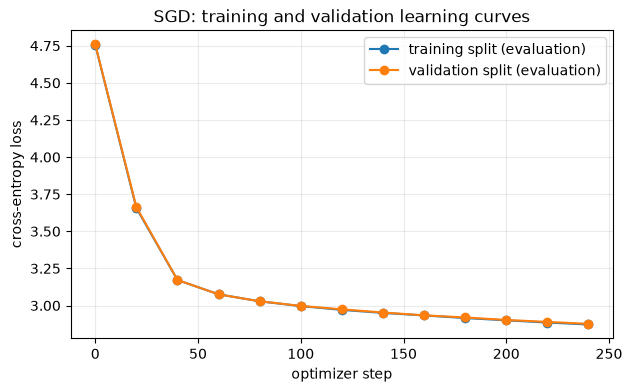

In [16]:
def plot_history(history, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["step"], history["train_loss"], marker="o", label="training split (evaluation)")
    ax.plot(history["step"], history["val_loss"], marker="o", label="validation split (evaluation)")
    ax.set(title=title, xlabel="optimizer step", ylabel="cross-entropy loss")
    ax.grid(alpha=0.25)
    ax.legend()
    return ax

plot_history(sgd_history, "SGD: training and validation learning curves")
plt.show()

### Why plotting matters

A final scalar hides the path taken to reach it. A curve can reveal:

- divergence or oscillation from an excessive learning rate;
- slow progress from a learning rate that is too small;
- a plateau suggesting underfitting;
- a widening train–validation gap suggesting overfitting;
- the checkpoint where validation loss was best.

Loss is lower when predictions are better. **Perplexity** is <code>exp(loss)</code>; it is often easier to interpret but contains the same information.

## 5. Underfitting and overfitting

| Pattern | Training loss | Validation loss | Typical response |
| --- | --- | --- | --- |
| Underfitting | high | high | train longer, improve optimization, or increase capacity |
| Good fit | lower | lower and close | keep the best validation checkpoint |
| Overfitting | keeps falling | stalls/rises; gap widens | stop earlier, use more data or regularization, reduce capacity |

These are diagnoses, not rigid thresholds. “High” is relative to the task and to stronger baselines.

### 5.1 Reproduce underfitting

We deliberately combine a smaller model with very few updates. This is **optimization/time underfitting**: the model has not even fitted the training set well.

Predict both curves before running.

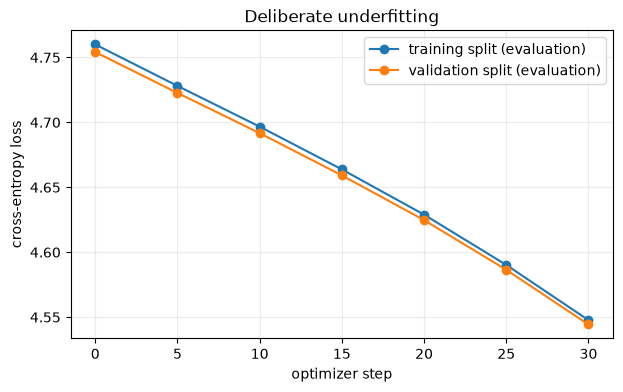

In [20]:
torch.manual_seed(10)
underfit_model = make_model(
    d_model=16,
    num_heads=2,
    d_ff=32,
    num_layers=1,
)
underfit_history = train_model(
    underfit_model,
    train_data,
    val_data,
    lr=0.05,
    batch_size=16,
    steps=30,
    eval_interval=5,
)

plot_history(underfit_history, "Deliberate underfitting")
plt.show()

### 5.2 Reproduce overfitting

Now we make memorization easy:

- only a few hundred training characters;
- a larger model;
- many SGD updates with a relatively large learning rate;
- evaluation on the original validation text.

The tiny training subset must still contain more than one context window. Validation data remains untouched.

**Leakage warning:** if we evaluated on the tiny training subset only, memorization would look like success.

**Do not confuse dataset size with vocabulary size:** `tiny_train_data = train_data[:384]` retains 384 character positions for training. The vocabulary size (101 for this corpus) is the number of distinct characters those positions may contain and the number of output classes predicted at every position.

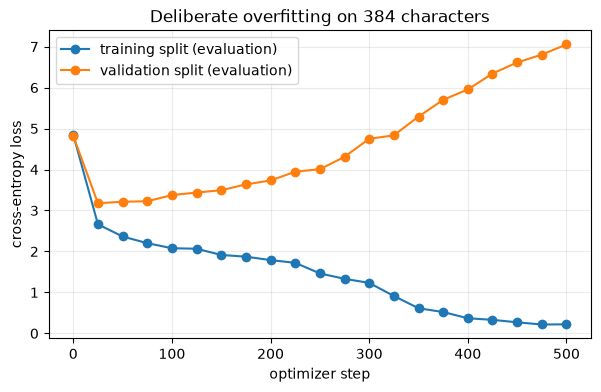

best validation step: 25
best validation loss: 3.176
final training loss: 0.220
final validation loss: 7.052


In [21]:
tiny_train_data = train_data[:384]  # 384 character tokens, not 384 vocabulary items

torch.manual_seed(10)
overfit_model = make_model(
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_layers=2,
)
overfit_history = train_model(
    overfit_model,
    tiny_train_data,
    val_data,
    lr=0.5,
    batch_size=16,
    steps=500,
    eval_interval=25,
)

plot_history(overfit_history, "Deliberate overfitting on 384 characters")
plt.show()

best_index = min(
    range(len(overfit_history["val_loss"])),
    key=overfit_history["val_loss"].__getitem__,
)
print("best validation step:", overfit_history["step"][best_index])
print(f"best validation loss: {overfit_history['val_loss'][best_index]:.3f}")
print(f"final training loss: {overfit_history['train_loss'][-1]:.3f}")
print(f"final validation loss: {overfit_history['val_loss'][-1]:.3f}")

🟧 Diagnose the plots:

1. At what step does validation loss reach its minimum?
2. Does training loss continue to improve after that point?
3. Is the problem in the overfitting run insufficient capacity, insufficient optimization, or poor generalization?
4. Which intervention would you try first: more steps, more training data, a larger model, or early stopping? Why?

## 6. Hyperparameters: controlled experiments (Optional)

A hyperparameter is chosen by us rather than learned by gradient descent.

| Hyperparameter | Main effect | If too small | If too large |
| --- | --- | --- | --- |
| Learning rate | update size | very slow learning | unstable/diverging loss |
| Batch size | examples per update | noisy gradient, cheap step | costly step, fewer updates for a fixed example budget |
| Number of steps | optimization time | underfitting | wasted compute or overfitting |
| Model size | capacity and compute | capacity underfitting | slower; easier to memorize |
| Context length | tokens visible per example | misses long dependencies | attention cost and memory grow quickly |

**Fair comparison matters.** Keep the model initialization, data, evaluation batches, and all non-tested choices fixed. Batch-size comparisons are subtle: holding steps fixed changes how many examples are processed.

### 6.1 Learning-rate experiment

Change one variable only. All models start from the same random seed and use the same batch sequence.

Before running, order the three learning rates from expected slowest to most unstable.

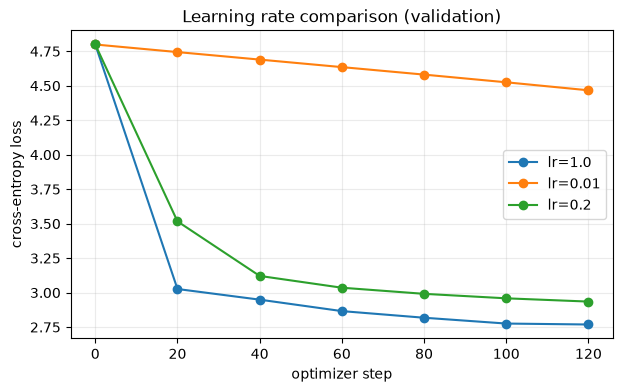

In [22]:
learning_rate_histories = {}

LR = [1.0, 0.01, 0.2]

for learning_rate in LR:
    torch.manual_seed(99)
    experiment_model = make_model()
    learning_rate_histories[learning_rate] = train_model(
        experiment_model,
        train_data,
        val_data,
            lr=learning_rate,
        batch_size=32,
        steps=120,
        eval_interval=20,
        eval_batches=3,
        seed=555,
    )

fig, ax = plt.subplots(figsize=(7, 4))
for learning_rate, history in learning_rate_histories.items():
    ax.plot(
        history["step"],
        history["val_loss"],
        marker="o",
        label=f"lr={learning_rate}",
    )
ax.set(
    title="Learning rate comparison (validation)",
    xlabel="optimizer step",
    ylabel="cross-entropy loss",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### 6.2 Batch-size

Run a controlled comparison with batch sizes 4, 32, and 128.

Choose and state the budget:

- **fixed steps:** larger batches process more examples; or
- **fixed examples/tokens:** larger batches get fewer optimizer updates.

Record runtime as well as validation loss. A batch size is a statistical **and** systems choice.

Optional starter:

    for batch_size in [4, 32, 128]:
        torch.manual_seed(99)
        model = make_model()
        history = train_model(...)
        # store history and number of examples processed

🟧 Explain why comparing 200 steps for every batch size does not hold total data exposure constant.